/Users/hwangdayoung/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


{0: np.float64(1.77), 1: np.float64(0.359), 2: np.float64(0.602), 3: np.float64(0.998), 4: np.float64(1.633), 5: np.float64(2.75), 6: np.float64(158.502)}
{0: np.float64(1.77), 1: np.float64(0.359), 2: np.float64(0.602), 3: np.float64(0.998), 4: np.float64(1.633), 5: np.float64(2.75), 6: 100.0}
Epoch 1/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 2s 930us/step - accuracy: 0.5224 - loss: 1.3680 - val_accuracy: 0.7001 - val_loss: 0.7758
Epoch 2/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - accuracy: 0.6396 - loss: 0.9575 - val_accuracy: 0.6999 - val_loss: 0.7300
Epoch 3/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step - accuracy: 0.6510 - loss: 0.8729 - val_accuracy: 0.6857 - val_loss: 0.7469
Epoch 4/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step - accuracy: 0.6484 - loss: 0.8599 - val_accuracy: 0.6771 - val_loss: 0.7618
Epoch 5/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.6591 - loss: 0.8050 - val_accuracy: 0.6773 - val_loss: 0.7508
Epoch 6/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           707 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,923 (249.70 KB)

 Trainable params: 21,307 (83.23 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 42,616 (166.47 KB)

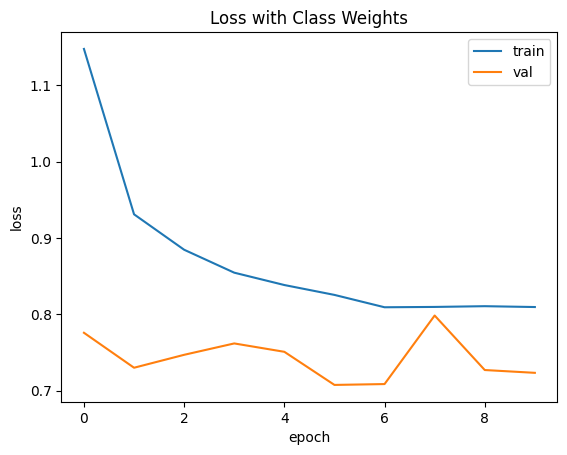

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras

FC = pd.read_csv('FC_new.csv')
feature = FC[['v','a','sin']].to_numpy()
target = FC['FC_Label'].to_numpy()
train_input, test_input, train_target, test_target = train_test_split(feature, target, test_size=0.4, random_state=42) 
val_input, test_input, val_target, test_target = train_test_split(test_input, test_target, test_size=0.5, random_state=42) 

model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(7, activation='softmax'))

class_counts = np.bincount(train_target.astype(int))
total_samples = len(train_target)
num_classes = len(class_counts)
class_weights = {}
for i, count in enumerate(class_counts):
    class_weights[i] = round((total_samples / (num_classes * count)), 3)

print(class_weights)
class_weights[6] = 100.0
print(class_weights)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_input, train_target, epochs=10, validation_data=(val_input, val_target), class_weight=class_weights)
model.summary()
model.save('FC_class_weighted2.keras')

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.title('Loss with Class Weights')
plt.show()


451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.7014 - loss: 0.7335
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 231us/step
Confusion Matrix:
 [[1044    1   47    2    4    0    0]
 [ 860 4361  552   22    8    0    0]
 [ 459   97 2310  446   77    2    0]
 [  34    1  469 1098  450   38    2]
 [   7    0   36  230  816  220    0]
 [   3    0    3   14  130  560    8]
 [   0    0    0    0    2   11    0]]
Accuracy: 0.706
Precision: [0.434 0.978 0.676 0.606 0.549 0.674 0.   ]
Recall (Sensitivity): [0.951 0.752 0.681 0.525 0.623 0.78  0.   ]
F1 Score: [0.596 0.85  0.679 0.562 0.584 0.723 0.   ]


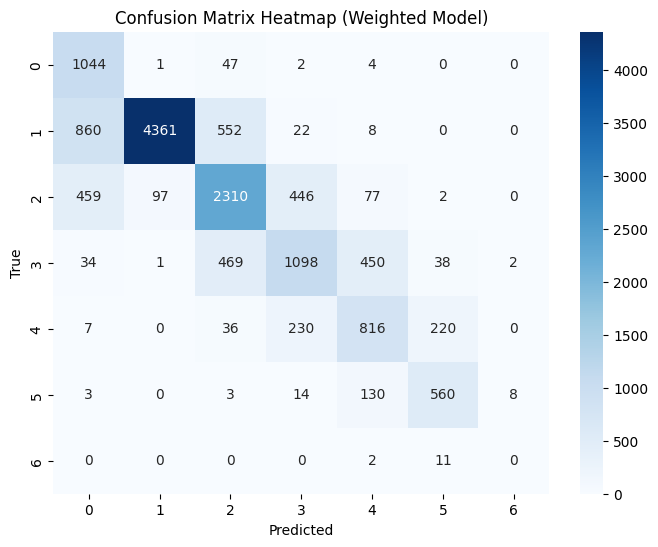

In [3]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

model.evaluate(test_input, test_target)
test_pred_weighted = np.argmax(model.predict(test_input), axis=1)
cm_weighted = confusion_matrix(test_target, test_pred_weighted)
accuracy_weighted = round(accuracy_score(test_target, test_pred_weighted), 3)
precision_weighted = precision_score(test_target, test_pred_weighted, average=None, zero_division=0).round(3)
recall_weighted = recall_score(test_target, test_pred_weighted, average=None, zero_division=0).round(3)
f1_weighted = f1_score(test_target, test_pred_weighted, average=None, zero_division=0).round(3)

print("Confusion Matrix:\n", cm_weighted)
print(f"Accuracy: {accuracy_weighted}")
print(f"Precision: {precision_weighted}")
print(f"Recall (Sensitivity): {recall_weighted}")
print(f"F1 Score: {f1_weighted}")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap (Weighted Model)")
plt.show()

In [11]:
import numpy as np

class_counts = np.array([32, 23, 30, 15])
total_samples = class_counts.sum()
num_classes = len(class_counts)
print(class_counts, total_samples, num_classes)

class_weights1 = {}
class_weights2 = {}

for i, count in enumerate(class_counts):
    class_weights1[i] = round((total_samples / (num_classes * count)), 3)
    class_weights2[i] = round((total_samples / (count)), 3)

print(class_weights1)
print(class_weights2)


[32 23 30 15] 100 4
{0: np.float64(0.781), 1: np.float64(1.087), 2: np.float64(0.833), 3: np.float64(1.667)}
{0: np.float64(3.125), 1: np.float64(4.348), 2: np.float64(3.333), 3: np.float64(6.667)}
